In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle, warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv('data/Students Performance.csv')

# Drop Student_ID
df = df.drop(columns=['Student_ID'])

# Drop the 1 missing row in Scholarship
df = df.dropna()

print(df.shape)         
print(df['Grade'].value_counts())  

(144, 14)
Grade
AA      35
BA      24
BB      21
CC      17
DD      17
DC      13
CB       9
Fail     8
Name: count, dtype: int64


In [30]:
# ── Cell 3: Clean & Encode (NaN-safe version) ──────────────────────

df = pd.read_csv('data/Students Performance.csv')

# 1. Drop Student_ID
df = df.drop(columns=['Student_ID'])

# 2. Strip whitespace from ALL string columns (hidden spaces cause NaN in map)
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

# 3. Drop missing values
df = df.dropna()
print("After dropna:", df.shape)

# 4. Binary Yes/No columns → 0/1
binary_cols = ['Additional_Work', 'Sports_activity', 'Reading',
               'Notes', 'Listening_in_Class', 'Project_work']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 5. Sex → 0/1
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# 6. Check if map() left any NaN (catches typos like 'yes' vs 'Yes')
print("\nNaN check after binary encoding:")
print(df[binary_cols + ['Sex']].isnull().sum())

# 7. Fix any remaining NaN from map() mismatches
df = df.dropna()
print("After second dropna:", df.shape)

# 8. One-hot encode multi-category columns
df = pd.get_dummies(df, columns=[
    'Student_Age',
    'High_School_Type',
    'Scholarship',
    'Transportation',
    'Attendance'
], drop_first=False)   # keep all dummies for clarity

# 9. Encode target Grade
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Grade_encoded'] = le.fit_transform(df['Grade'])
df = df.drop(columns=['Grade'])

# 10. Final NaN check — must be all zeros
print("\n Final NaN check (all must be 0):")
print(df.isnull().sum()[df.isnull().sum() > 0])  # prints only problem cols
print("Shape:", df.shape)
print("Classes:", le.classes_)

After dropna: (144, 14)

NaN check after binary encoding:
Additional_Work       0
Sports_activity       0
Reading               0
Notes                 2
Listening_in_Class    1
Project_work          0
Sex                   0
dtype: int64
After second dropna: (141, 14)

 Final NaN check (all must be 0):
Series([], dtype: int64)
Shape: (141, 25)
Classes: ['AA' 'BA' 'BB' 'CB' 'CC' 'DC' 'DD' 'Fail']


In [32]:
feature_cols = [c for c in df.columns if c != 'Grade_encoded']

X = df[feature_cols]
y = df['Grade_encoded']

# Safety check before split
assert X.isnull().sum().sum() == 0, "❌ NaN still in X!"
assert y.isnull().sum() == 0,       "❌ NaN in y!"
print("No NaN found — safe to split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

No NaN found — safe to split
Train: (112, 24) | Test: (29, 24)


Logistic Regression       | CV: 0.215 ± 0.069 | Test: 0.276
Decision Tree             | CV: 0.189 ± 0.062 | Test: 0.207
Random Forest             | CV: 0.266 ± 0.080 | Test: 0.276
Gradient Boosting         | CV: 0.215 ± 0.054 | Test: 0.310


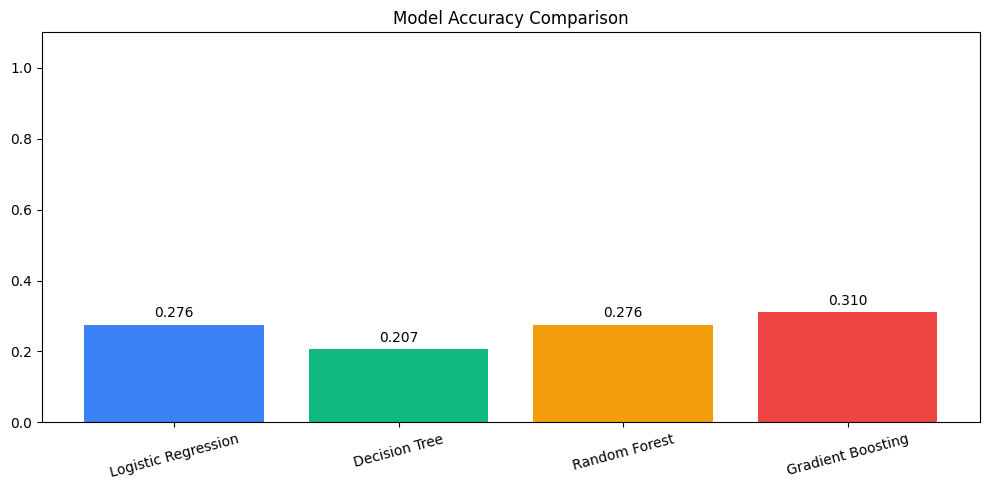

In [33]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    # Cross-validation (better for 144 rows)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(), 'Test Acc': test_acc}
    print(f"{name:25} | CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} | Test: {test_acc:.3f}")

# Plot model comparison
plt.figure(figsize=(10, 5))
names = list(results.keys())
test_scores = [results[n]['Test Acc'] for n in names]
bars = plt.bar(names, test_scores, color=['#3B82F6','#10B981','#F59E0B','#EF4444'])
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.ylim(0, 1.1)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs/plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Cell 5: Hyperparameter Tuning (Random Forest) ──────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search with 5-fold CV
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1   # progress output
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_, 3))
print("Test accuracy:", round(accuracy_score(y_test, best_model.predict(X_test)), 3))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score: 0.304
Test accuracy: 0.414


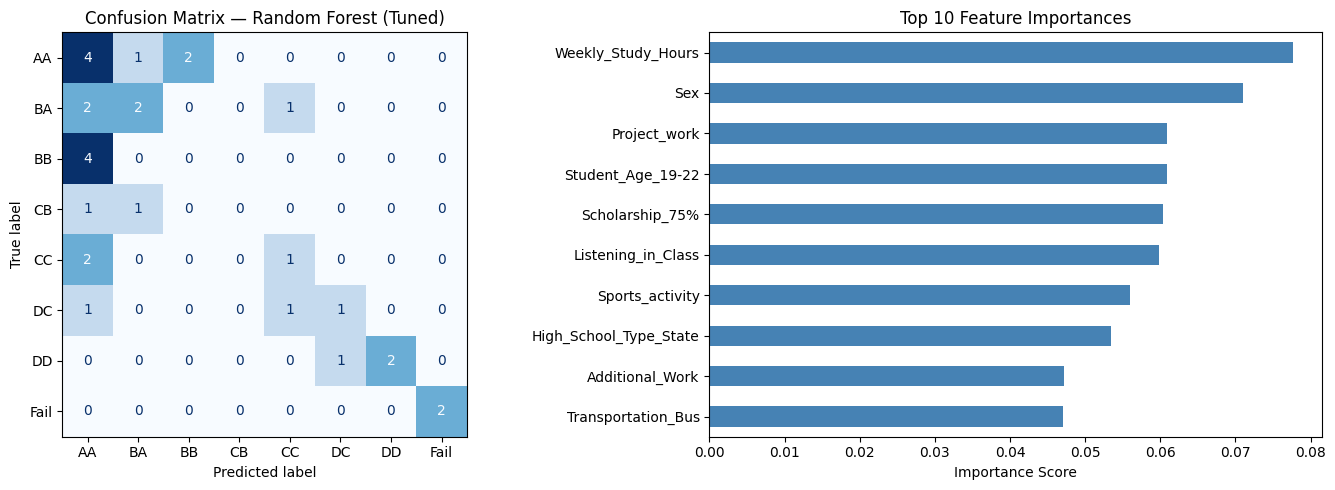


              precision    recall  f1-score   support

          AA       0.29      0.57      0.38         7
          BA       0.50      0.40      0.44         5
          BB       0.00      0.00      0.00         4
          CB       0.00      0.00      0.00         2
          CC       0.33      0.33      0.33         3
          DC       0.50      0.33      0.40         3
          DD       1.00      0.67      0.80         3
        Fail       1.00      1.00      1.00         2

    accuracy                           0.41        29
   macro avg       0.45      0.41      0.42        29
weighted avg       0.41      0.41      0.40        29



In [26]:
y_pred = best_model.predict(X_test)

# --- Confusion Matrix ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix — Random Forest (Tuned)')

# --- Feature Importance ---
feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols)
feat_imp.nlargest(10).sort_values().plot(
    kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Top 10 Feature Importances')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/plots/confusion_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Full report ---
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_))

In [34]:
with open('outputs/model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'label_encoder': le, 'features': feature_cols}, f)

print("Model saved to outputs/model.pkl")

Model saved to outputs/model.pkl
